# Ejercicios para Prácticas Python

###  Ejercicio 1: Limpieza y análisis básico de datos (Pandas + lógica Python)

* Contexto: Te dan un CSV con datos de clientes de un ecommerce:
``` python
data = {
    "cliente_id": [1, 2, 3, 4, 5, 6],
    "edad": [25, 35, None, 29, 41, 33],
    "genero": ["M", "F", "F", "F", None, "M"],
    "pais": ["MX", "MX", "CO", "MX", "CO", "AR"],
    "total_compras": [3, 5, 2, None, 4, 1]
}
```

* Tareas:
  - Imputa los valores faltantes en edad y total_compras con la media.
  - Imputa los valores faltantes de genero con la moda.
  - Crea una nueva columna cliente_valioso (True si hizo ≥4 compras).
  - ¿Cuál es el promedio de edad por país?

***NOTAS***
* `fillna` este es muy bueno para llenar los valores.
* `isnull()` es muy bueno para los nones.
* Modificaciones deben ser guardadas en el Df original.
* `dropna=True` ignora los valores faltantes (NaN) cuando busca la moda.
* ¿Por qué usamos [0] al final?: Porque ***`.mode()` devuelve una Serie*** (no un solo valor), y necesitamos el primer valor más frecuente (aunque haya empate).

In [27]:
import pandas as pd

data = {
    "cliente_id": [1, 2, 3, 4, 5, 6],
    "edad": [25, 35, None, 29, 41, 33],
    "genero": ["M", "F", "F", "F", None, "M"],
    "pais": ["MX", "MX", "CO", "MX", "CO", "AR"],
    "total_compras": [3, 5, 2, None, 4, 1]
}

compras = pd.DataFrame(data)
print("="*5, "ORIGINAL", "="*5,"\n")
print(compras, "\n")

# 1. Sustituir edad y total compras con la media
compras['edad'] = compras['edad'].fillna(compras['edad'].mean())
compras['total_compras'] = compras['total_compras'].fillna(compras['total_compras'].mean())
print("="*5, "Punto 1", "="*5,"\n")
print(compras, "\n")

# 2. Remplazar con la moda los generos faltantes.
moda_genero = compras["genero"].mode(dropna=True)[0]
compras["genero"] = compras["genero"].fillna(moda_genero)
print("="*5, "Punto 2", "="*5,"\n")
print(compras, "\n")

# 3. Crea una nueva columna cliente_valioso (True si hizo ≥4 compras)
compras["cliente_valioso"] = compras["total_compras"] > 4
print("="*5, "Punto 3", "="*5,"\n")
print(compras, "\n")

# 4. ¿Cuál es el promedio de edad por país?
edad_prom = compras.groupby("pais")["edad"].mean().reset_index()
print("="*5, "Punto 4", "="*5,"\n")
print(edad_prom, "\n")

===== ORIGINAL ===== 

   cliente_id  edad genero pais  total_compras
0           1  25.0      M   MX            3.0
1           2  35.0      F   MX            5.0
2           3   NaN      F   CO            2.0
3           4  29.0      F   MX            NaN
4           5  41.0   None   CO            4.0
5           6  33.0      M   AR            1.0 

===== Punto 1 ===== 

   cliente_id  edad genero pais  total_compras
0           1  25.0      M   MX            3.0
1           2  35.0      F   MX            5.0
2           3  32.6      F   CO            2.0
3           4  29.0      F   MX            3.0
4           5  41.0   None   CO            4.0
5           6  33.0      M   AR            1.0 

===== Punto 2 ===== 

   cliente_id  edad genero pais  total_compras
0           1  25.0      M   MX            3.0
1           2  35.0      F   MX            5.0
2           3  32.6      F   CO            2.0
3           4  29.0      F   MX            3.0
4           5  41.0      F   CO     

* Solución

In [29]:
df = compras.copy()
df["edad"] = df["edad"].fillna(df["edad"].mean())
df["total_compras"] = df["total_compras"].fillna(df["total_compras"].mean())
df["genero"] = df["genero"].fillna(df["genero"].mode()[0])
df["cliente_valioso"] = df["total_compras"] > 4
edad_prom = df.groupby("pais", as_index=False)["edad"].mean()
print(df, "\n")

   cliente_id  edad genero pais  total_compras  cliente_valioso
0           1  25.0      M   MX            3.0            False
1           2  35.0      F   MX            5.0             True
2           3  32.6      F   CO            2.0            False
3           4  29.0      F   MX            3.0            False
4           5  41.0      F   CO            4.0            False
5           6  33.0      M   AR            1.0            False 



### Ejercicio 2: NumPy y condiciones

* Contexto: Simula lecturas de temperatura en 5 sensores durante 10 días.

``` python
np.random.seed(42)
temperaturas = np.random.normal(loc=25, scale=5, size=(10, 5))  # 10 días, 5 sensores
```

* Tareas:
  - ¿Cuál fue la temperatura más alta registrada?
  - ¿Cuántos valores estuvieron fuera del rango aceptable [15°C, 35°C]?
  - Normaliza los datos por sensor (MinMaxScaler manual con NumPy).

***NOTAS***
* `df.select_dtypes(include="number").values.max()`: nos ayuda a sacar el valor máximo de un dataframe o arreglo.
* `select_dtypes()` es una función muy útil de pandas que te permite seleccionar columnas de un DataFrame según su tipo de dato (por ejemplo, numérico, texto, booleano, etc.)
* `df.select_dtypes(include='number')` es lo mismo que `df.select_dtypes(include=['int64', 'float64'])`.
* ***Siempre que nos pidan trabajar una condición en todo el DataFrame podemos transformalo a array*** usando `df.values`

In [39]:
import numpy as np
from sklearn import preprocessing

#Establecemos la semilla de generación
np.random.seed(42)
# Los datos seguiran una media de 25 y una desviación de 5
temperaturas = np.random.normal(loc=25, scale=5, size=(10, 5))  # 10 días, 5 sensores
df = pd.DataFrame(temperaturas)
print("="*5, "ORIGINAL", "="*5,"\n")
print(df, "\n")

# 1. ¿Cuál fue la temperatura más alta registrada?
print("="*5, "Punto 1", "="*5,"\n")
max_val = df.select_dtypes(include="number").values.max()
print("Máximo valor numérico:", max_val)

# 2. ¿Cuántos valores estuvieron fuera del rango aceptable [15°C, 35°C]?
print("="*5, "Punto 2", "="*5,"\n")
valores = df.values  # convierte a array NumPy
fuera_rango = (valores < 15) | (valores > 35)
cantidad_fuera = np.sum(fuera_rango)
print("Cantidad de Datos fuera del Rango establecido:", cantidad_fuera)

# 3. Normaliza los datos por sensor (MinMaxScaler manual con NumPy) 
print("="*5, "Punto 3", "="*5,"\n")
datos_min_max = preprocessing.MinMaxScaler().fit_transform(df)
print("datos_min_max", datos_min_max)

# Modo Manual
min_val = np.min(valores, axis=0)
max_val = np.max(valores, axis=0)

# Aplicar fórmula del MinMaxScaler manual
datos_normalizados = (valores - min_val) / (max_val - min_val)
print("\nDatos normalizados Munualmente:\n", datos_normalizados)

===== ORIGINAL ===== 

           0          1          2          3          4
0  27.483571  24.308678  28.238443  32.615149  23.829233
1  23.829315  32.896064  28.837174  22.652628  27.712800
2  22.682912  22.671351  26.209811  15.433599  16.375411
3  22.188562  19.935844  26.571237  20.459880  17.938481
4  32.328244  23.871118  25.337641  17.876259  22.278086
5  25.554613  19.245032  26.878490  21.996807  23.541531
6  21.991467  34.261391  24.932514  19.711445  29.112725
7  18.895782  26.044318  15.201649  18.359070  25.984306
8  28.692333  25.856841  24.421759  23.494482  17.607390
9  21.400779  22.696806  30.285611  26.718091  16.184799 

===== Punto 1 ===== 

Máximo valor numérico: 34.26139092254469
===== Punto 2 ===== 

Cantidad de Datos fuera del Rango establecido: 0
===== Punto 3 ===== 

datos_min_max [[0.63933097 0.33720867 0.86428178 1.         0.59131173]
 [0.36728438 0.90907737 0.903975   0.42016169 0.89171315]
 [0.28193862 0.22817243 0.72979249 0.         0.01474418]
 [0.

* Solución 

In [43]:
# 1. Sacar el valor mayor de todo un data frame
max_val = df.values.max()
print(max_val)
max_val = np.max(df.to_numpy())
print(max_val)

# 2. Rango
fuera_rango = (valores < 15) | (valores > 35)
print(f"Número de temperaturas fuera de [15, 35]: {np.count_nonzero(fuera_rango)}")

# 3. Escalar

34.26139092254469
34.26139092254469
Número de temperaturas fuera de [15, 35]: 0


### Ejercicio 3: Visualización con matplotlib y seaborn

* Contexto: Genera visualizaciones a partir de este DataFrame de ventas:

``` python
ventas = pd.DataFrame({
    "mes": ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"],
    "sucursal_A": [200, 220, 250, 230, 260, 300],
    "sucursal_B": [180, 210, 200, 190, 240, 250]
})
```

* Tareas:
  - Grafica ambas series en una misma línea usando matplotlib.pyplot.
  - Usa seaborn para mostrar un boxplot comparando las dos sucursales.
  - Agrega etiquetas, título, y leyenda a la gráfica.

***NOTAS***
* 

===== ORIGINAL ===== 

       mes  sucursal_A  sucursal_B
0    Enero         200         180
1  Febrero         220         210
2    Marzo         250         200
3    Abril         230         190
4     Mayo         260         240
5    Junio         300         250 



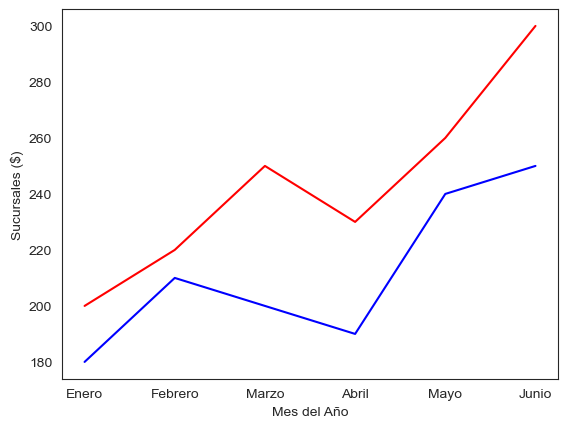

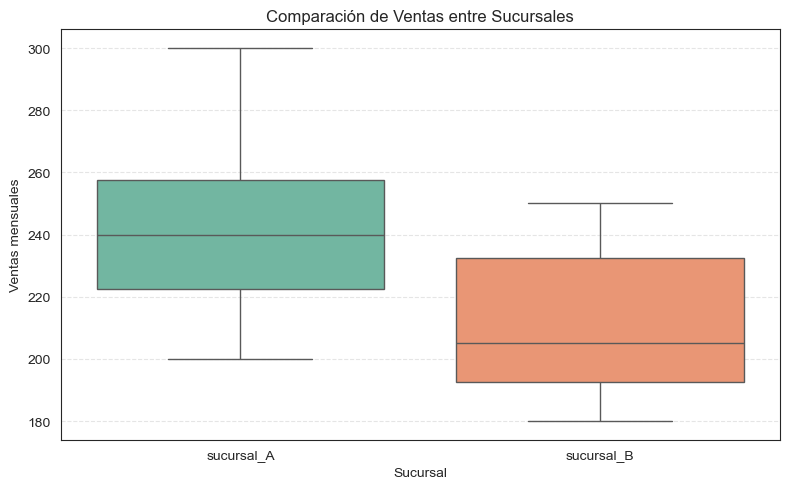

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

ventas = pd.DataFrame({
    "mes": ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"],
    "sucursal_A": [200, 220, 250, 230, 260, 300],
    "sucursal_B": [180, 210, 200, 190, 240, 250]
})

print("="*5, "ORIGINAL", "="*5,"\n")
print(ventas, "\n")

# 1. Grafica ambas series en una misma línea usando matplotlib.pyplot.
plt.plot(ventas['mes'],ventas['sucursal_A'], color="red")
plt.plot(ventas['mes'],ventas['sucursal_B'], color="blue")
plt.ylabel("Sucursales ($)")
plt.xlabel("Mes del Año")
plt.show()

# 2. Usa seaborn para mostrar un boxplot comparando las dos sucursales.
ventas_largo = ventas.melt(id_vars="mes", 
                           value_vars=["sucursal_A", "sucursal_B"],
                           var_name="sucursal",
                           value_name="ventas")

# Estilo del fondo y boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=ventas_largo,
    x="sucursal",
    y="ventas",
    hue="sucursal",        # ahora usa hue
    palette="Set2",
    legend=False           # evita mostrar dos leyendas
)

plt.title("Comparación de Ventas entre Sucursales")
plt.ylabel("Ventas mensuales")
plt.xlabel("Sucursal")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

* Solución

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Enero'),
  Text(1, 0, 'Febrero'),
  Text(2, 0, 'Marzo'),
  Text(3, 0, 'Abril'),
  Text(4, 0, 'Mayo'),
  Text(5, 0, 'Junio')])

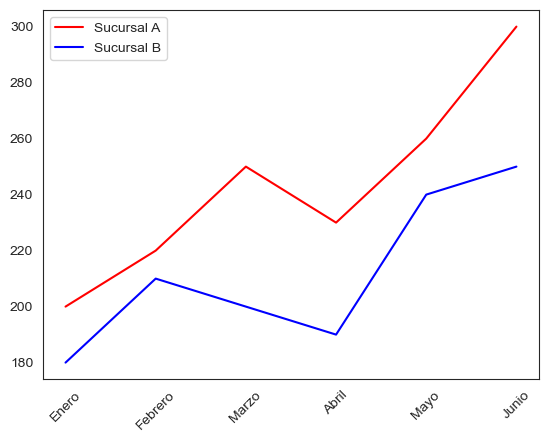

In [56]:
plt.plot(ventas['mes'], ventas['sucursal_A'], color="red", label="Sucursal A")
plt.plot(ventas['mes'], ventas['sucursal_B'], color="blue", label="Sucursal B")
plt.legend()
plt.xticks(rotation=45)

### Ejercicio 4: Estilo entrevista de datos

* Contexto: Supón que te dan una tabla de reseñas de productos.
``` python
reseñas = pd.DataFrame({
    "producto_id": ["A", "B", "A", "A", "C", "B", "C", "C", "B", "A"],
    "calificacion": [5, 3, 4, 2, 5, 1, 4, 3, 2, 5]
})
```
* Tareas:
  - Calcula el promedio de calificación por producto.
  - ¿Qué producto tiene la mayor variabilidad en sus reseñas?
  - Crea un gráfico de barras con el promedio de calificaciones.

***NOTA***
* `print(variabilidad.loc[variabilidad.idxmax()], "\n")`: esto solo nos traeel maximo de cada columna.
* Usas `.loc[]` cuando quieres acceder por el nombre del índice o columnas. `df.loc[fila, columna]`. Etiquetas. `df.loc["a", "edad"]  # → 22` .
* Usas `.iloc[]` cuando quieres acceder por posición numérica (como si fuera un arreglo). Posiciones numéricas. `df.iloc[0, 1]`.
* Para las gráficas de barra literal usamos `barplot` de ***Seaborn*** o `bar` de `matplotlib.pyplot`.

===== Original ===== 

  producto_id  calificacion
0           A             5
1           B             3
2           A             4
3           A             2
4           C             5
5           B             1
6           C             4
7           C             3
8           B             2
9           A             5 

===== Punto 1 ===== 

   index producto_id  calificacion
0      0           A           4.0
1      1           B           2.0
2      2           C           4.0 

===== Punto 2 ===== 

   index producto_id  calificacion
0      0           A           2.0
1      1           B           1.0
2      2           C           1.0 

Producto con la máxima variabilidad:
 A , Calificacion: 2.0 



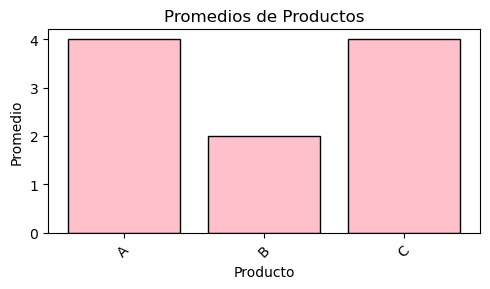

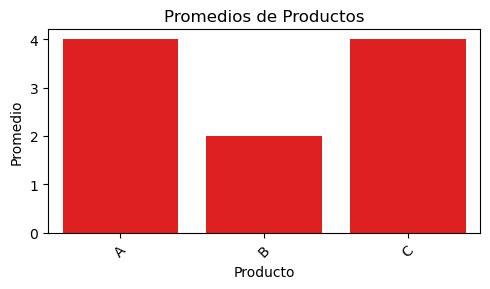

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

reseñas = pd.DataFrame({
    "producto_id": ["A", "B", "A", "A", "C", "B", "C", "C", "B", "A"],
    "calificacion": [5, 3, 4, 2, 5, 1, 4, 3, 2, 5]
})

print("="*5, "Original", "="*5,"\n")
print(reseñas, "\n")

### 1. Calcula el promedio de calificación por producto.
promedio_producto = reseñas.groupby("producto_id", as_index=False)["calificacion"].mean().reset_index()
print("="*5, "Punto 1", "="*5,"\n")
print(promedio_producto, "\n")

### 2. ¿Qué producto tiene la mayor variabilidad en sus reseñas?
variabilidad = reseñas.groupby("producto_id", as_index=False)["calificacion"].var().reset_index() # Nos regresa un tada frame.
producto_max_var = variabilidad.loc[variabilidad["calificacion"].idxmax()]
print("="*5, "Punto 2", "="*5,"\n")
print(variabilidad, "\n")
print("Producto con la máxima variabilidad:\n", producto_max_var.iloc[1], ", Calificacion:", producto_max_var.iloc[2],"\n")

### 3. Crea un gráfico de barras con el promedio de calificaciones.
plt.figure(figsize=(5, 3))

plt.bar(
    promedio_producto["producto_id"],
    promedio_producto["calificacion"],
    color="pink",
    edgecolor="black"
)

plt.title("Promedios de Productos")
plt.xlabel("Producto")
plt.ylabel("Promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Usando seaborn
plt.figure(figsize=(5, 3))
sns.barplot(
    data=promedio_producto,
    x="producto_id",
    y="calificacion",
    color="red"
)
plt.title("Promedios de Productos")
plt.xlabel("Producto")
plt.ylabel("Promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

***SOLUCIÓN***
*  Detalle técnico menor: como ya pusiste as_index=False, el .reset_index() es innecesario, y de hecho, causa que el DataFrame tenga dos niveles de índices al final. Basta con `promedio_producto = reseñas.groupby("producto_id", as_index=False)["calificacion"].mean()`. Mismo caso para `variabilidad `.

Producto con mayor variabilidad: A, Varianza: 2.00


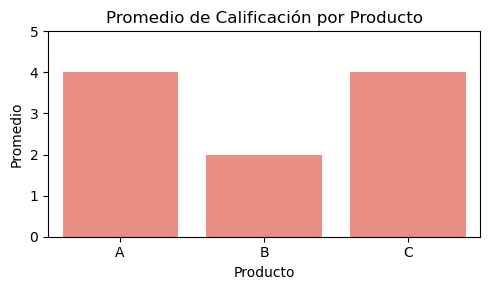

In [39]:
# 1. Promedios
promedio_producto = reseñas.groupby("producto_id", as_index=False)["calificacion"].mean()

# 2. Variabilidad
variabilidad = reseñas.groupby("producto_id", as_index=False)["calificacion"].var()
producto_max_var = variabilidad.loc[variabilidad["calificacion"].idxmax()]

print(f"Producto con mayor variabilidad: {producto_max_var['producto_id']}, Varianza: {producto_max_var['calificacion']:.2f}")

# 3. Gráfico seaborn
plt.figure(figsize=(5, 3))
sns.barplot(data=promedio_producto, x="producto_id", y="calificacion", color="salmon")
plt.title("Promedio de Calificación por Producto")
plt.xlabel("Producto")
plt.ylabel("Promedio")
plt.ylim(0, 5)  # Por ser calificaciones de 1 a 5
plt.tight_layout()
plt.show()

### Ejercicio 5: Mini-proyecto (nivel entrevista práctica)

* Contexto: Datos simulados de sesiones de usuarios en un sitio web.
``` python
usuarios = pd.DataFrame({
    "usuario_id": [1, 2, 3, 1, 4, 2, 5, 1, 3, 4],
    "duracion_sesion": [300, 180, 240, 120, 600, 200, 150, 100, 90, 400],
    "acciones": [5, 3, 4, 2, 10, 3, 1, 1, 2, 8]
})
```
* Tareas:
  - Calcula la duración total por usuario.
  - Crea una métrica llamada "acciones por minuto".
  - Grafica un scatterplot de duración total vs. acciones por minuto.
  - ¿Qué usuarios parecen ser más activos?

===== Original ===== 

   usuario_id  duracion_sesion  acciones
0           1              300         5
1           2              180         3
2           3              240         4
3           1              120         2
4           4              600        10
5           2              200         3
6           5              150         1
7           1              100         1
8           3               90         2
9           4              400         8 

===== Punto 1 ===== 

   usuario_id  duracion_sesion
0           1              520
1           2              380
2           3              330
3           4             1000
4           5              150 

===== Punto 2 ===== 

   usuario_id  duracion_sesion  acciones  acciones_minuto
0           1              300         5            60.00
1           2              180         3            60.00
2           3              240         4            60.00
3           1              120         2            60.00
4 

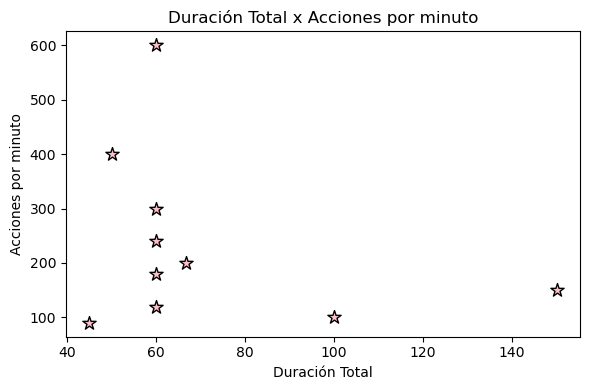

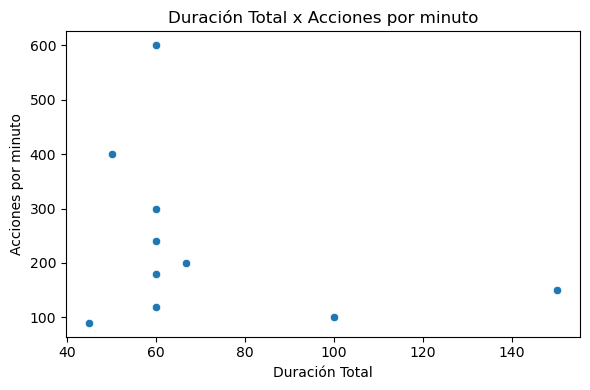

===== Punto 5 ===== 

   usuario_id  acciones_minuto
0           1        73.333333
1           2        63.335000
2           3        52.500000
3           4        55.000000
4           5       150.000000 

El usuario con mayor actividad es 5.0 con un promedio de 150.0 acciones por minuto


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

usuarios = pd.DataFrame({
    "usuario_id": [1, 2, 3, 1, 4, 2, 5, 1, 3, 4],
    "duracion_sesion": [300, 180, 240, 120, 600, 200, 150, 100, 90, 400],
    "acciones": [5, 3, 4, 2, 10, 3, 1, 1, 2, 8]
})
print("="*5, "Original", "="*5,"\n")
print(usuarios, "\n")

### 1. Calcula la duración total por usuario.
duracion_usuarios = usuarios.groupby("usuario_id", as_index=False)['duracion_sesion'].sum()
print("="*5, "Punto 1", "="*5,"\n")
print(duracion_usuarios, "\n")

### 2. Crea una métrica llamada "acciones por minuto"
usuarios["acciones_minuto"] = round(usuarios["duracion_sesion"] / usuarios["acciones"], 2)
print("="*5, "Punto 2", "="*5,"\n")
print(usuarios, "\n")

### 3. Grafica un scatterplot de duración total vs. acciones por minuto.
plt.figure(figsize=(6, 4))
plt.scatter(
    x=usuarios["acciones_minuto"],
    y=usuarios["duracion_sesion"],
    color="pink",
    edgecolor="black",
    marker="*",
    s=100
)
plt.title("Duración Total x Acciones por minuto")
plt.xlabel("Duración Total")
plt.ylabel("Acciones por minuto")
plt.tight_layout()
plt.show()

# Con Seaborn.
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=usuarios,
    x="acciones_minuto",
    y="duracion_sesion",
    markers="o"
)
plt.title("Duración Total x Acciones por minuto")
plt.xlabel("Duración Total")
plt.ylabel("Acciones por minuto")
plt.tight_layout()
plt.show()

### 4. ¿Qué usuarios parecen ser más activos?
actividad_usuarios = usuarios.groupby("usuario_id", as_index=False)['acciones_minuto'].mean() # Obtenemos el dataframe
usuario_max_actividad = actividad_usuarios.loc[actividad_usuarios["acciones_minuto"].idxmax()]
print("="*5, "Punto 5", "="*5,"\n")
print(actividad_usuarios, "\n")
print(f"El usuario con mayor actividad es {usuario_max_actividad.iloc[0]} con un promedio de {usuario_max_actividad.iloc[1]} acciones por minuto")

***SOLUCIÓN***

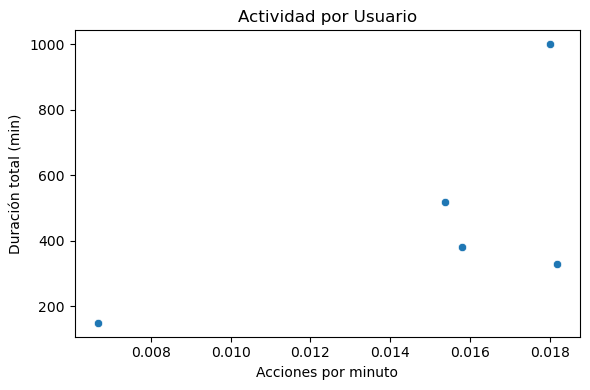

Usuario más activo: 3.0, con 0.02 acciones/minuto


In [59]:
# Calcular duración total y acciones totales por usuario
resumen = usuarios.groupby("usuario_id", as_index=False).agg({
    "duracion_sesion": "sum",
    "acciones": "sum"
})
resumen["acciones_por_minuto"] = resumen["acciones"] / resumen["duracion_sesion"]

# Visualización
plt.figure(figsize=(6, 4))
sns.scatterplot(data=resumen, x="acciones_por_minuto", y="duracion_sesion")
plt.title("Actividad por Usuario")
plt.xlabel("Acciones por minuto")
plt.ylabel("Duración total (min)")
plt.tight_layout()
plt.show()

# Usuario más activo (más acciones en menos tiempo)
usuario_mas_activo = resumen.loc[resumen["acciones_por_minuto"].idxmax()]
print(f"Usuario más activo: {usuario_mas_activo['usuario_id']}, con {usuario_mas_activo['acciones_por_minuto']:.2f} acciones/minuto")